In [5]:
import torch
import torchvision

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split

import matplotlib.pyplot as plt

In [6]:
import os

os.listdir()

['.config', '.ipynb_checkpoints', 'processed_dataset_v2.zip', 'sample_data']

In [7]:
!unzip -q /content/processed_dataset_v2.zip


In [8]:
!ls

processed_dataset_v2  processed_dataset_v2.zip	sample_data


In [9]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

cuda


In [10]:
DATASET_DIR = r"/content/processed_dataset_v2"

In [11]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [12]:
dataset = ImageFolder(
    DATASET_DIR,
    transform=transform
)

print("Total Images:", len(dataset))

print("Classes:")
print(dataset.classes)

Total Images: 2000
Classes:
['destroyed', 'major-damage', 'minor-damage', 'no-damage']


In [13]:
train_size = int(
    0.8 * len(dataset)
)

val_size = (
    len(dataset)
    - train_size
)

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print(len(train_dataset))
print(len(val_dataset))

1600
400


In [14]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [15]:
images, labels = next(
    iter(train_loader)
)

print(images.shape)

print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


In [16]:
print("Total Images:", len(dataset))
print(dataset.classes)
print(images.shape)
print(labels.shape)

Total Images: 2000
['destroyed', 'major-damage', 'minor-damage', 'no-damage']
torch.Size([32, 3, 224, 224])
torch.Size([32])


In [17]:
import torch.nn as nn

class BuildingDamageCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(
                128 * 28 * 28,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.3),

            nn.Linear(
                512,
                4
            )
        )

    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x

In [18]:
model = BuildingDamageCNN()

model = model.to(device)

print(model)

BuildingDamageCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=4, bias=True)
  )
)


In [19]:
criterion = nn.CrossEntropyLoss()

In [20]:
import torch.optim as optim

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

In [21]:
def train_one_epoch():

    model.train()

    running_loss = 0

    correct = 0

    total = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

    accuracy = 100 * correct / total

    return (
        running_loss / len(train_loader),
        accuracy
    )

In [22]:
def validate():

    model.eval()

    correct = 0

    total = 0

    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)

            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            val_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

    accuracy = 100 * correct / total

    return (
        val_loss / len(val_loader),
        accuracy
    )

In [23]:
EPOCHS = 10

In [24]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch()

    val_loss, val_acc = validate()

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Acc : {train_acc:.2f}%"
    )

    print(
        f"Val Loss  : {val_loss:.4f}"
    )

    print(
        f"Val Acc   : {val_acc:.2f}%"
    )

    print("-"*40)

Epoch 1/10
Train Loss: 1.4117
Train Acc : 31.62%
Val Loss  : 1.3075
Val Acc   : 41.00%
----------------------------------------
Epoch 2/10
Train Loss: 1.2458
Train Acc : 42.94%
Val Loss  : 1.1351
Val Acc   : 46.00%
----------------------------------------
Epoch 3/10
Train Loss: 1.1402
Train Acc : 51.56%
Val Loss  : 1.0793
Val Acc   : 53.50%
----------------------------------------
Epoch 4/10
Train Loss: 0.9933
Train Acc : 58.44%
Val Loss  : 1.1032
Val Acc   : 59.00%
----------------------------------------
Epoch 5/10
Train Loss: 0.8859
Train Acc : 64.62%
Val Loss  : 0.9743
Val Acc   : 61.75%
----------------------------------------
Epoch 6/10
Train Loss: 0.7686
Train Acc : 68.50%
Val Loss  : 1.0727
Val Acc   : 57.75%
----------------------------------------
Epoch 7/10
Train Loss: 0.6177
Train Acc : 76.62%
Val Loss  : 0.9939
Val Acc   : 64.00%
----------------------------------------
Epoch 8/10
Train Loss: 0.4950
Train Acc : 81.94%
Val Loss  : 1.0694
Val Acc   : 61.75%
-----------------

In [25]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

import numpy as np

In [26]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(
            outputs,
            1
        )

        all_preds.extend(
            preds.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

In [27]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=dataset.classes
    )
)

              precision    recall  f1-score   support

   destroyed       0.75      0.71      0.73       106
major-damage       0.58      0.43      0.49       101
minor-damage       0.53      0.48      0.51       102
   no-damage       0.50      0.74      0.60        91

    accuracy                           0.58       400
   macro avg       0.59      0.59      0.58       400
weighted avg       0.60      0.58      0.58       400



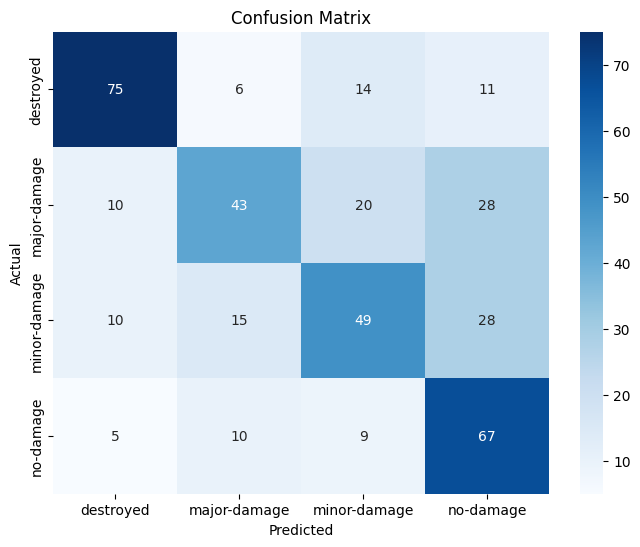

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(
    all_labels,
    all_preds
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=dataset.classes,
    yticklabels=dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets
from torchvision import transforms
from torchvision.models import efficientnet_b0

from torch.utils.data import DataLoader
from torch.utils.data import random_split

from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
DATASET_DIR = "/content/processed_dataset_v2"

In [31]:
import os

print(os.path.exists(DATASET_DIR))

True


In [32]:
transform = transforms.Compose([

    transforms.Resize((224,224)),

    transforms.RandomHorizontalFlip(),

    transforms.RandomRotation(10),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [33]:
dataset = datasets.ImageFolder(
    DATASET_DIR,
    transform=transform
)

print(len(dataset))
print(dataset.classes)

2000
['destroyed', 'major-damage', 'minor-damage', 'no-damage']


In [34]:
train_size = int(
    0.8 * len(dataset)
)

val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size]
)

print(len(train_dataset))
print(len(val_dataset))

1600
400


In [35]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

In [36]:
model = efficientnet_b0(
    weights="DEFAULT"
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 109MB/s] 


In [37]:
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features,
    4
)

model = model.to(device)

print(model)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [44]:
for param in model.features.parameters():
    param.requires_grad = True

In [45]:
criterion = nn.CrossEntropyLoss()

In [46]:
optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=0.0001
)

In [47]:
model.parameters()

<generator object Module.parameters at 0x7f176d932420>

In [48]:
EPOCHS = 10

In [49]:
train_losses = []
val_losses = []

train_accs = []
val_accs = []

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch()

    val_loss, val_acc = validate()

    print(
        f"Epoch {epoch+1}/{EPOCHS}"
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Acc : {train_acc:.2f}%"
    )

    print(
        f"Val Loss  : {val_loss:.4f}"
    )

    print(
        f"Val Acc   : {val_acc:.2f}%"
    )

    print("-"*40)

Epoch 1/10
Train Loss: 0.7140
Train Acc : 73.12%
Val Loss  : 0.8058
Val Acc   : 67.75%
----------------------------------------
Epoch 2/10
Train Loss: 0.7264
Train Acc : 71.88%
Val Loss  : 0.7872
Val Acc   : 67.75%
----------------------------------------
Epoch 3/10
Train Loss: 0.7351
Train Acc : 71.25%
Val Loss  : 0.7722
Val Acc   : 66.50%
----------------------------------------
Epoch 4/10
Train Loss: 0.7304
Train Acc : 72.38%
Val Loss  : 0.7722
Val Acc   : 67.50%
----------------------------------------
Epoch 5/10
Train Loss: 0.7343
Train Acc : 72.19%
Val Loss  : 0.8095
Val Acc   : 64.75%
----------------------------------------
Epoch 6/10
Train Loss: 0.7326
Train Acc : 71.62%
Val Loss  : 0.7859
Val Acc   : 68.00%
----------------------------------------
Epoch 7/10
Train Loss: 0.7328
Train Acc : 71.19%
Val Loss  : 0.7966
Val Acc   : 67.00%
----------------------------------------
Epoch 8/10
Train Loss: 0.7254
Train Acc : 73.12%
Val Loss  : 0.8026
Val Acc   : 65.50%
-----------------